# 06 — The solver kernel in C++: same answer, real speedup, and the retrieval it powers

The one demanding primitive in this whole project is the **time-stepping solver
march** — the Crank–Nicolson kernel that advances the temperature column hour by
hour. The retrieval calls it dozens of times; everything else is thin Python
around it. This notebook is entirely about that kernel:

1. **It exists in three forms** — interpreted generic Python, the production
   **Numba** (`@njit`) kernel, and a standalone **C++** port (`cpp/solver.cpp`) —
   that implement the *identical* algorithm. We compile the C++ right here and
   confirm all three agree to double-precision round-off.
2. **How much the compiled versions buy** — the speed difference, fairly measured.
3. **The real workload** — we run the actual K_d retrieval loop live, with a
   progress bar, and see exactly what the backend choice costs.
4. **The retrieval, *in* C++** — we drive the whole retrieval by brute force
   through the C++ binary, and discover why that *still* isn't the fast path: the
   win is the anchor algorithm (Notebook 2), not the language.

> How a "C++ notebook" works: Python stays the **driver** — it serialises the
> inputs to one binary blob, launches the compiled executable with `subprocess`,
> and reads the temperature field back. The C++ file has no Python inside it; the
> notebook orchestrates it.

In [1]:
# --- setup: repo root + the Python<->C++ harness ------------------------------
import sys, json, time, tempfile, pathlib
import numpy as np, matplotlib.pyplot as plt

from lunar._bootstrap import find_repo_root
CODE = find_repo_root()                       # .../Lunar-Clean/code
REPO = CODE.parent                            # repo root (holds figures/)
sys.path.insert(0, str(CODE / "pipeline" / "compute"))
import benchmark_cpp as bc                     # dump_inputs / run_cpp / run_py (reused, not duplicated)

from lunar.config import GRID, DT_STEP, SITES, KD_GRIDS
from lunar.grid import make_geometric_grid
from lunar.solver import standard_insolation, periodic_time_grid
from lunar.plotting import style               # applies the house rcParams
from lunar.plotting.style import fmt_axis, C_A15, C_TEAL, C_DIM, C_GRID
plt.rcParams.update({"figure.dpi": 82, "savefig.dpi": 82})   # lean inline PNGs

g   = make_geometric_grid(**GRID)
t   = periodic_time_grid(DT_STEP)
n_t = t.size

print(f"grid: {g.z_mid.size} cells to {g.z_mid[-1]:.1f} m, {n_t} steps/lunation")
print(f"repo: {REPO}")

grid: 69 cells to 4.8 m, 1417 steps/lunation
repo: /Users/rp3gregorio/Developer/Lunar-Clean


## 1. Three engines, one algorithm — and they agree

`cpp/solver.cpp` reimplements the compiled Python kernel (`solver._march_radiative_hayne`) line-for-line: Crank–Nicolson step, midpoint-Picard property sweeps, Newton surface balance, Thomas solve, and the cycle-closing wrap step — same equations, same order of operations. First we compile it, then we run all three engines on identical inputs and demand they match.

The Python↔C++ plumbing is `benchmark_cpp.py` (imported as `bc`): `dump_inputs` serialises the grid, forcing, and initial state to one binary blob, `run_cpp` launches the compiled executable and reads the temperature field back, and `run_py` runs the same march in Numba (`fast=True`) or interpreted Python (`fast=False`).

In [2]:
# rebuild the C++ binary if solver.cpp changed since the last compile
import subprocess
src, binp = CODE/"cpp"/"solver.cpp", CODE/"cpp"/"lunar_solver"
if not binp.exists() or src.stat().st_mtime > binp.stat().st_mtime:
    print("compiling:", " ".join(["clang++","-O3","-std=c++17","-o",binp.name,src.name]))
    subprocess.run(["clang++","-O3","-std=c++17","-o",str(binp),str(src)], check=True)
print("C++ binary ready:", binp.relative_to(REPO))


C++ binary ready: code/cpp/lunar_solver


In [3]:
# run ALL THREE engines on identical inputs and check they agree to round-off
site   = SITES["A15"]
N_LUN  = 5
insol  = standard_insolation(site["lat"], t)
T_init = np.full(g.z_mid.size, site["T_MEAN_EFF"])

with tempfile.TemporaryDirectory() as td:
    inp, outp = pathlib.Path(td)/"in.bin", pathlib.Path(td)/"out.bin"
    bc.dump_inputs(inp, g, t, insol, T_init, site, N_LUN)
    s_cpp,  T_cpp  = bc.run_cpp(inp, outp, g.z_mid.size, t.size)     # C++ port
s_njit, T_njit = bc.run_py(g, t, insol, T_init, site, N_LUN, fast=True)   # Numba kernel
s_gen,  T_gen  = bc.run_py(g, t, insol, T_init, site, N_LUN, fast=False)  # generic interpreted

d_nc = np.max(np.abs(T_njit - T_cpp))
d_gc = np.max(np.abs(T_gen  - T_cpp))
print(f"max |T_Numba   - T_C++| = {d_nc:.2e} K")
print(f"max |T_generic - T_C++| = {d_gc:.2e} K")
print("=> all three are the SAME algorithm; they agree to double-precision round-off"
      if max(d_nc, d_gc) < 1e-9 else "DIVERGED -- investigate before trusting either!")


max |T_Numba   - T_C++| = 1.17e-12 K
max |T_generic - T_C++| = 6.82e-13 K
=> all three are the SAME algorithm; they agree to double-precision round-off


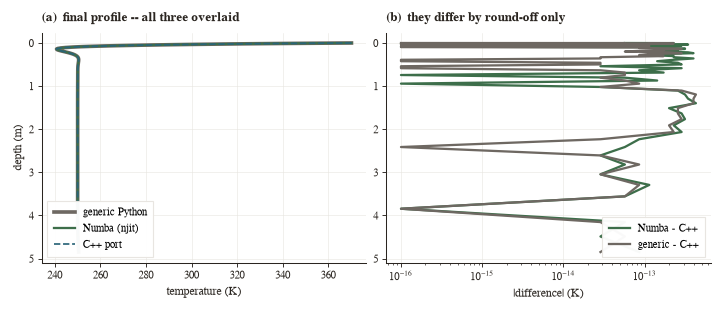

In [4]:
# see the agreement: the final-time profile from each engine, and their difference
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.6, 3.6), constrained_layout=True)
a1.plot(T_gen[:, -1],  g.z_mid, "-",  color=C_DIM,  lw=3.2, label="generic Python")
a1.plot(T_njit[:, -1], g.z_mid, "-",  color=C_A15,  lw=2.0, label="Numba (njit)")
a1.plot(T_cpp[:, -1],  g.z_mid, "--", color=C_TEAL, lw=1.5, label="C++ port")
a1.invert_yaxis()
fmt_axis(a1, xlabel="temperature (K)", ylabel="depth (m)",
         title="(a)  final profile -- all three overlaid")
a1.legend(frameon=True, edgecolor=C_GRID, loc="lower left")
a2.semilogx(np.abs(T_njit[:, -1] - T_cpp[:, -1]) + 1e-16, g.z_mid, color=C_A15, label="Numba - C++")
a2.semilogx(np.abs(T_gen[:, -1]  - T_cpp[:, -1]) + 1e-16, g.z_mid, color=C_DIM, label="generic - C++")
a2.invert_yaxis()
fmt_axis(a2, xlabel="|difference| (K)", title="(b)  they differ by round-off only")
a2.legend(frameon=True, edgecolor=C_GRID, loc="lower right")
plt.show()


## 2. The speed difference — generic Python vs. Numba vs. C++

Same answer, wildly different cost. The fair way to compare is **steady-state ms per lunation** (many lunations, so Numba's one-time JIT compile is amortised) — archived in `results/cpp_benchmark.json`. Panel (a) spans the two decades from interpreted Python to compiled code; panel (b) zooms in on the two compiled engines, which sit within ~1.5× of each other because they compile the *same* kernel to machine code.

solver march, steady-state ms per lunation (results/cpp_benchmark.json):
  generic Python     545.74 ms/lun    x   1.0 vs generic Python
  Numba (njit)         4.63 ms/lun    x 117.9 vs generic Python
  C++ port             3.20 ms/lun    x 170.3 vs generic Python

  C++ is x1.45 the Numba rate -- same order, because both compile the SAME kernel to machine code.


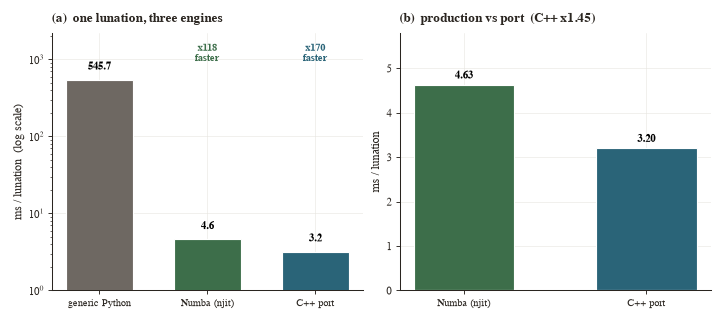

In [5]:
# --- the speed difference, illustrated -----------------------------------------
# Fair steady-state rates come from results/cpp_benchmark.json (50 lunations,
# median of 3, so Numba's one-time ~0.2 s JIT-compile is fully amortised).
bench = json.loads((CODE/"results"/"cpp_benchmark.json").read_text())
rows = [("generic Python", bench["py_ms_per_lunation"],      C_DIM),
        ("Numba (njit)",    bench["py_njit_ms_per_lunation"], C_A15),
        ("C++ port",        bench["cpp_ms_per_lunation"],     C_TEAL)]
labels, vals, cols = [r[0] for r in rows], [r[1] for r in rows], [r[2] for r in rows]
base = vals[0]
print("solver march, steady-state ms per lunation (results/cpp_benchmark.json):")
for lab, v, _ in rows:
    print(f"  {lab:16s} {v:8.2f} ms/lun    x{base/v:6.1f} vs generic Python")
print(f"\n  C++ is x{vals[1]/vals[2]:.2f} the Numba rate -- same order, "
      f"because both compile the SAME kernel to machine code.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.6, 3.7), constrained_layout=True)
# (a) all three, log scale (spans two decades)
bars = a1.bar(range(3), vals, color=cols, width=0.62, edgecolor="white", zorder=3)
a1.set_yscale("log"); a1.set_xticks(range(3)); a1.set_xticklabels(labels, fontsize=9)
a1.set_ylim(1, base*4)
for i, v in enumerate(vals):
    a1.text(i, v*1.25, f"{v:.1f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
for i in (1, 2):
    a1.text(i, base*2.2, f"x{base/vals[i]:.0f}\nfaster", ha="center", va="center",
            fontsize=9, color=cols[i], fontweight="bold")
fmt_axis(a1, ylabel="ms / lunation  (log scale)", title="(a)  one lunation, three engines")
# (b) Numba vs C++, zoomed linear -- they are close
a2.bar([0, 1], vals[1:], color=cols[1:], width=0.55, edgecolor="white", zorder=3)
a2.set_xticks([0, 1]); a2.set_xticklabels(["Numba (njit)", "C++ port"], fontsize=9)
a2.set_ylim(0, max(vals[1:])*1.25)
for i, v in enumerate(vals[1:]):
    a2.text(i, v+0.08, f"{v:.2f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
fmt_axis(a2, ylabel="ms / lunation",
         title=f"(b)  production vs port  (C++ x{vals[1]/vals[2]:.2f})")
plt.show()


## 3. The real workload — the K_d retrieval, with a progress bar

Everything above times *one* march. The actual science is the **K_d retrieval**:
for each candidate $K_d$, solve the model to periodic steady state and score it
against the Apollo sensors — the demanding loop that runs the kernel dozens of
times. Below we run the real sweep live — the *same* `run_kd_sweep_extended` the
pipeline calls — with a `tqdm` progress bar so you can watch it, landing on the
published $K_d^*$ at each site.

*(A few "not fully converged" warnings print near the top of each sweep: those
are the high-$K_d$ candidates far above the minimum, where the deep column
relaxes slowest. They sit nowhere near the RMSE vertex, so $K_d^*$ is unaffected.)*

In [6]:
from retrieve_kd import run_kd_sweep_extended, kd_star_from_residuals

kd_star = {}
for name in ("A15", "A17"):
    t0 = time.perf_counter()
    _, _, R, _ = run_kd_sweep_extended(SITES[name], KD_GRIDS[name])   # tqdm bar prints here
    ks, rmse = kd_star_from_residuals(R, KD_GRIDS[name])
    dt = time.perf_counter() - t0
    kd_star[name] = ks
    n = len(KD_GRIDS[name])
    print(f"{name}:  K_d* = {ks*1e3:.3f} mW/m/K   (RMSE {rmse:.3f} K; "
          f"{n} solves in {dt:.0f} s = {dt/n:.2f} s/solve)")

Lunar-V2 notebook bootstrap
  python : /Users/rp3gregorio/Developer/Lunar-Clean/.venv/bin/python
  repo   : /Users/rp3gregorio/Developer/Lunar-Clean/code
  deps   : all present
  lunar  : /Users/rp3gregorio/Developer/Lunar-Clean/code/src/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


Ensuring Apollo HFE (a17) ...


K_d sweep Apollo 15 hayne:   0%|          | 0/29 [00:00<?, ?Kd/s]

A15:  K_d* = 4.600 mW/m/K   (RMSE 1.000 K; 29 solves in 25 s = 0.87 s/solve)


K_d sweep Apollo 17 hayne:   0%|          | 0/32 [00:00<?, ?Kd/s]

A17:  K_d* = 7.079 mW/m/K   (RMSE 0.398 K; 32 solves in 28 s = 0.87 s/solve)


### What the backend buys on this workload

That sweep ran the solver once per candidate $K_d$. Here is what the *same*
retrieval costs in plain interpreted Python versus the compiled kernel — the
reason the C++ port (and the Numba kernel it certifies) matters.

In [7]:
spd = json.loads((CODE / "results" / "speedup_benchmark.json").read_text())
n_solves = sum(len(KD_GRIDS[s]) for s in ("A15", "A17"))
print(f"the K_d retrieval runs the solver {n_solves} times (both sites).")
print(f"per-solve cost (results/speedup_benchmark.json) and the sweep it implies:\n")
print(f"  interpreted Python   {spd['t_anchored_s']:6.1f} s/solve   ->  "
      f"{spd['t_anchored_s']*n_solves/60:5.1f} min")
print(f"  compiled kernel      {spd['t_anchored_fast_s']:6.2f} s/solve   ->  "
      f"{spd['t_anchored_fast_s']*n_solves/60:5.1f} min")
print(f"\n  ~{spd['speedup_per_solve']:.0f}x faster per solve. The C++ port matches the compiled")
print(f"  kernel's march rate (section 2) -- it is the independent reference that")
print(f"  certifies the fast path the pipeline actually runs.")

the K_d retrieval runs the solver 61 times (both sites).
per-solve cost (results/speedup_benchmark.json) and the sweep it implies:

  interpreted Python     74.7 s/solve   ->   75.9 min
  compiled kernel        0.64 s/solve   ->    0.6 min

  ~21x faster per solve. The C++ port matches the compiled
  kernel's march rate (section 2) -- it is the independent reference that
  certifies the fast path the pipeline actually runs.


## 4. Running the retrieval *through* the C++ kernel — and what it teaches

Section 3 used the kernel inside the *anchor method* (fast, exact). Now the
opposite: drive the retrieval by **brute force through the C++ binary** — for each
candidate $K_d$, march the column toward steady state in C++, score it against the
sensors, find the vertex. This is literally "the retrieval, in C++." Watch what
happens to the answer.

In [8]:
from retrieve_kd import kd_star_from_residuals, _interp_profile_at_depths
from lunar.apollo_helpers import extract_sensor_stability
from tqdm.auto import tqdm

N_LUN_BF = 3000                        # brute-force lunations per K_d
site     = SITES["A15"]
insol_bf = standard_insolation(site["lat"], t)
obs   = extract_sensor_stability(site["mission"], min_depth_cm=site["MIN_DEPTH_CM"])
z_obs = np.asarray(obs["depth_cm_all"]) / 100.0
T_obs = np.asarray(obs["T_eq_all"])
deep  = np.asarray(obs["deep_mask"], dtype=bool)
z_deep, T_deep = z_obs[deep], T_obs[deep]

# focused K_d grid bracketing the A15 minimum (keeps this a few minutes)
kd_grid_bf = np.linspace(4.0, 5.4, 15) * 1e-3

R = np.empty((len(z_deep), len(kd_grid_bf)))
for k, kd in enumerate(tqdm(kd_grid_bf, desc="C++ brute-force retrieval (A15)", unit="Kd")):
    T_init = np.full(g.z_mid.size, site["T_MEAN_EFF"])           # flat start
    with tempfile.TemporaryDirectory() as td:
        inp, outp = pathlib.Path(td) / "i.bin", pathlib.Path(td) / "o.bin"
        bc.dump_inputs(inp, g, t, insol_bf, T_init, site, N_LUN_BF, kd=kd)   # C++ marches N lunations
        _, T = bc.run_cpp(inp, outp, g.z_mid.size, t.size)
    R[:, k] = _interp_profile_at_depths(z_deep, g.z_mid, T.mean(axis=1),
                                        context="cpp brute force") - T_deep

kd_bf, _ = kd_star_from_residuals(R, kd_grid_bf, warn_coarse=False)
kd_anchor = kd_star["A15"]             # from section 3 (the anchor method)
print(f"\nC++ brute force ({N_LUN_BF} lunations/K_d) : K_d* = {kd_bf*1e3:.3f} mW/m/K")
print(f"anchor method (section 3)               : K_d* = {kd_anchor*1e3:.3f} mW/m/K")
print(f"gap = {(kd_anchor-kd_bf)*1e3:.3f} mW/m/K  <-  brute force is still under-converged")

C++ brute-force retrieval (A15):   0%|          | 0/15 [00:00<?, ?Kd/s]


C++ brute force (3000 lunations/K_d) : K_d* = 4.478 mW/m/K
anchor method (section 3)               : K_d* = 4.600 mW/m/K
gap = 0.121 mW/m/K  <-  brute force is still under-converged


### The lesson

The C++ kernel is **correct** — Section 1 showed it matches Python to 10⁻¹² K.
Yet the brute-force retrieval lands *below* the anchor-method value. Nothing is
wrong with C++; the problem is **brute force itself**: even 3000 lunations leaves
the deep column still creeping upward (Notebook 2, §1), so the fit compensates
with a lower $K_d$. Push the lunations higher and it crawls toward 4.600 — but
you would wait the better part of an hour.

**That is the whole point of the flux-anchored method.** It reaches the *exact*
steady state directly, so the retrieval gets 4.600 in seconds — not because Numba
is faster than C++ (it isn't; §2), but because the *algorithm* skips the slow
spin-up entirely. C++ is the independent reference that proves the kernel is
right; the anchor method is what makes the science tractable. **The win was the
method, not the language.**

## 📎 Code this notebook uses

| Piece | Code |
|---|---|
| the C++ kernel (one march) | `code/cpp/solver.cpp` (compiled with `clang++`) |
| Python↔C++ harness (serialise → run → read back) | `pipeline/compute/benchmark_cpp.py` (`dump_inputs`, `run_cpp`, `run_py`) |
| the archived fair timings | `results/cpp_benchmark.json`, `results/speedup_benchmark.json` |
| the K_d retrieval loop (with tqdm) | `pipeline/compute/retrieve_kd.py` (`run_kd_sweep_extended`, `kd_star_from_residuals`) |
| driving the C++ kernel across a K_d sweep | `benchmark_cpp.dump_inputs(..., kd=)` → `run_cpp` (§4) |

The kernel is the only demanding primitive; the equilibrium outer loop, the $K_d$
sweep, and the bootstrap are all thin Python around it. That is why one fast,
verified march — Numba in production, C++ as the reference — makes the whole
retrieval cheap. And §4 is the punchline: even the C++ kernel, run by brute force,
can't cheaply reproduce $K_d^*$ — the flux-anchored *method* (Notebook 2) is what
does. The full retrieval (3-layer sweep, bootstrap, error budget) runs in
**`03_retrieval.ipynb`**.